# GPT Tabanlı Metin Üretim Modelinin PyTorch ile Sıfırdan Geliştirilmesi

## Proje Özeti

Bu projede PyTorch kullanılarak decoder-only Transformer mimarisi ile çalışan GPT benzeri bir büyük dil modeli geliştirilmiştir.

Model:
- TinyStories veri seti üzerinde eğitilmiştir
- Byte Pair Encoding (BPE) tokenizer kullanmaktadır
- Rotary Positional Embeddings (RoPE) içermektedir
- Masked Causal Self-Attention mekanizması kullanmaktadır
- Otoregresif metin üretimi gerçekleştirmektedir

Modelin amacı:
- İngilizce kısa hikaye üretmek
- Tutarlı metin üretmek
- Basit açıklamalar oluşturmak

Bu proje tamamen sıfırdan geliştirilmiş olup hazır Transformer modelleri kullanılmamıştır.

# 1. Giriş

Üretken Yapay Zeka modelleri son yıllarda doğal dil işleme alanındaki en önemli gelişmelerden biri haline gelmiştir. GPT (Generative Pretrained Transformer) modelleri, verilen bir metin dizisine göre sonraki tokeni tahmin ederek otoregresif şekilde metin üretmektedir.

Bu projenin amacı, önceden eğitilmiş transformer modelleri kullanılmadan tamamen sıfırdan bir GPT benzeri decoder-only Transformer geliştirmektir.

Projede özellikle:
- transformer mimarisinin anlaşılması,
- attention mekanizmasının manuel implementasyonu,
- tokenizer geliştirilmesi,
- dil modeli eğitimi,
- ve metin üretimi

konularına odaklanılmıştır.

Sistem, sınırlı donanım üzerinde çalışabilecek şekilde optimize edilmiştir.

In [1]:
import torch
import yaml
import numpy as np

from tokenizers import Tokenizer

from model.gpt import GPT
from training.dataset import GPTDataset

# Konfigürasyon Dosyasının Yüklenmesi

Bu bölümde modelin:
- vocab size
- layer sayısı
- attention head sayısı
- embedding boyutu
- eğitim parametreleri

yüklenmektedir.

In [2]:
with open("configs/small.yaml", "r") as f:
    config = yaml.safe_load(f)

config

{'vocab_size': 16000,
 'block_size': 256,
 'n_layer': 8,
 'n_head': 8,
 'd_model': 512,
 'dropout': 0.1,
 'batch_size': 16,
 'accumulation_steps': 8,
 'learning_rate': 0.0003,
 'min_lr': 3e-05,
 'max_iters': 12000,
 'eval_interval': 100,
 'eval_iters': 20,
 'weight_decay': 0.1,
 'beta1': 0.9,
 'beta2': 0.95,
 'grad_clip': 1.0,
 'warmup_steps': 500,
 'device': 'cuda',
 'dtype': 'float16'}

# Tokenizer Yükleme

Bu projede Byte Pair Encoding (BPE) tokenizer kullanılmıştır.

Tokenizer:
- TinyStories veri seti üzerinde eğitilmiştir
- 16.000 vocabulary boyutuna sahiptir
- Alt kelime (subword) temelli çalışmaktadır

In [3]:
tokenizer = Tokenizer.from_file("tokenizer/tokenizer.json")

print("Tokenizer başarıyla yüklendi.")
print("Vocabulary boyutu:", tokenizer.get_vocab_size())

Tokenizer başarıyla yüklendi.
Vocabulary boyutu: 16000


# Tokenizer Testi

Bu bölümde tokenizer:
1. Metni tokenlara ayırır
2. Token ID'leri üretir
3. Tekrar metne dönüştürür

Bu işlem tokenizer'ın doğru çalıştığını doğrular.

In [4]:
sample = """
Once upon a time, there was a little girl named Lily.
She loved playing outside with her friends.
"""

encoding = tokenizer.encode(sample)

decoded = tokenizer.decode(encoding.ids)

print("ORIGINAL:")
print(sample)

print("\nTOKEN IDS:")
print(encoding.ids[:30])

print("\nDECODED:")
print(decoded)

ORIGINAL:

Once upon a time, there was a little girl named Lily.
She loved playing outside with her friends.


TOKEN IDS:
[110, 108, 8001, 305, 127, 264, 15, 256, 153, 127, 262, 304, 360, 211, 17, 108, 4894, 362, 454, 519, 209, 178, 336, 17, 108]

DECODED:
 
once upon a time, there was a little girl named lily.
she loved playing outside with her friends.



# Veri Seti Yükleme

Model eğitimi sırasında:
- giriş dizisi (x)
- hedef dizisi (y)

oluşturulmaktadır.

Hedef dizisi giriş dizisinin bir sonraki token kaydırılmış halidir.

In [5]:
dataset = GPTDataset(
    "data/processed/train_ids.npy",
    block_size=config["block_size"]
)

x, y = dataset[0]

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print("\nİlk 20 input token:")
print(x[:20])

print("\nİlk 20 target token:")
print(y[:20])

Input shape: torch.Size([256])
Target shape: torch.Size([256])

İlk 20 input token:
tensor([ 763,  979,  186,  129,  700,  437,   17,  108,  108, 4201,  153,  201,
        1490,  135,  372,  201,  270,  220,  139,  302])

İlk 20 target token:
tensor([ 979,  186,  129,  700,  437,   17,  108,  108, 4201,  153,  201, 1490,
         135,  372,  201,  270,  220,  139,  302,  136])


# GPT Modelinin Oluşturulması

Model aşağıdaki bileşenlerden oluşmaktadır:

- Token Embedding
- Transformer Block
- Multi-Head Self Attention
- Feed Forward Network
- Layer Normalization
- Linear Output Head

Model decoder-only mimarisine sahiptir.

In [6]:
model = GPT(config)

total_params = sum(p.numel() for p in model.parameters())

print(model)

print("\nToplam Parametre Sayısı:")
print(f"{total_params:,}")

GPT(
  (token_emb): Embedding(16000, 512)
  (blocks): ModuleList(
    (0-7): 8 x TransformerBlock(
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (qkv_proj): Linear(in_features=512, out_features=1536, bias=False)
        (out_proj): Linear(in_features=512, out_features=512, bias=False)
        (rope): RoPE()
      )
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=512, out_features=16000, bias=False)
)

Toplam Parametre Sayısı:
33,395,712


# Forward Pass Testi

Bu bölümde modele rastgele giriş verileri verilerek:
- boyut kontrolü
- logits üretimi
- model stabilitesi

test edilmektedir.

In [7]:
dummy_input = torch.randint(
    0,
    config["vocab_size"],
    (2, 32)
)

with torch.no_grad():
    logits = model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([2, 32])
Logits shape: torch.Size([2, 32, 16000])


# Eğitilmiş Modelin Yüklenmesi

Bu bölümde eğitim sonrası kaydedilen checkpoint dosyası yüklenmektedir.

In [8]:
device = config["device"]

checkpoint = torch.load(
    "experiments/checkpoints/best.pt",
    map_location=device
)

model.load_state_dict(checkpoint["model"])

model.to(device)

model.eval()

print("Checkpoint başarıyla yüklendi.")

Checkpoint başarıyla yüklendi.


# Metin Üretimi

Model autoregressive yöntemle:
- bir sonraki tokenı tahmin eder
- tahmini girişe ekler
- yeni token üretmeye devam eder

Üretim sırasında:
- temperature sampling
- top-k sampling
- top-p sampling

kullanılmıştır.

In [11]:
from inference.generate import generate

prompt = "once upon a time"

input_ids = tokenizer.encode(prompt).ids

idx = torch.tensor([input_ids], dtype=torch.long).to(device)

out = generate(
    model=model,
    tokenizer=tokenizer,
    idx=idx,
    max_new_tokens=80,
    block_size=config["block_size"],
    temperature=0.8,
    top_k=40,
    top_p=0.9
)

generated_text = tokenizer.decode(out[0].tolist())

print(generated_text)

 once upon a time, there was a little girl named lily. she loved to draw and make things with her crayons. one day, she drew a picture of a big purple flower and wanted to show it to her mommy.

lily went to the kitchen and said, "mommy, look at my flower! i have an idea!" 

her mommy smiled and said, "that's very nice, lily


# Attention Görselleştirmesi

Transformer modellerinde attention mekanizması:
- modelin hangi tokenlara odaklandığını
- bağlam ilişkilerini
- dikkat dağılımını

göstermektedir.

Attention map oluşturuluyor...


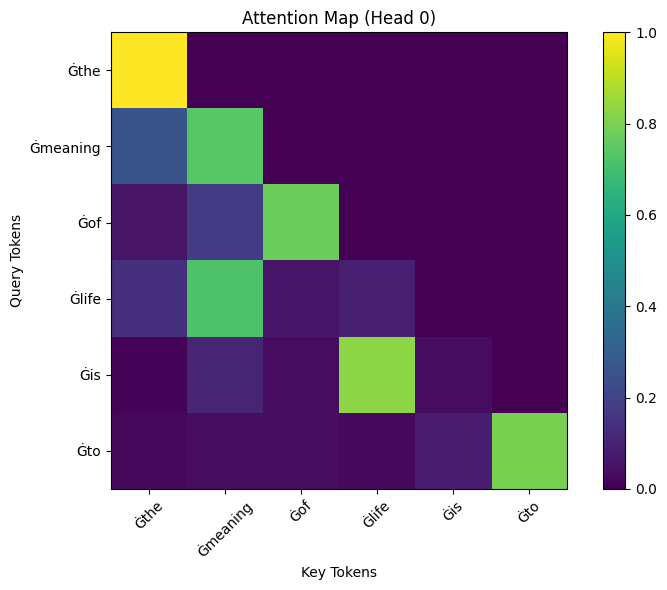

In [10]:
from evaluation.visualize_attention import main

print("Attention map oluşturuluyor...")

main()

# Eğitim Süreci

Model TinyStories veri seti üzerinde eğitilmiştir.

Kullanılan teknikler:
- Mixed Precision Training
- Gradient Clipping
- AdamW Optimizer
- Cosine Learning Rate Scheduler
- Gradient Accumulation

Bu teknikler:
- daha stabil eğitim
- daha düşük VRAM kullanımı
- daha hızlı eğitim

sağlamaktadır.

# Sonuç

Bu projede PyTorch kullanılarak sıfırdan GPT benzeri bir büyük dil modeli geliştirilmiştir.

Model:
- anlamlı kısa hikayeler üretebilmiş
- dil yapısını öğrenebilmiş
- temel bağlam ilişkilerini kurabilmiştir

Bu çalışma sayesinde:
- Transformer mimarisi
- attention mekanizması
- tokenizer yapısı
- otoregresif metin üretimi

detaylı şekilde anlaşılmıştır.

Gelecek çalışmalarda:
- daha büyük veri setleri
- daha büyük model boyutları
- instruction tuning
- RLHF

gibi yöntemlerle model daha da geliştirilebilir.